## import thư viện

In [ ]:
!pip install transformers==4.57.3 accelerate==1.12.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 380.9/380.9 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 21.0 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.11.0
    Uninstalling huggingface_hub-1.11.0:
      Successfully uninstalled huggingface_hub-1.11.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0
  Attempting uninstall: accelerate
    Found existing installation: accelerate 1.13.0
    Uninstalling accelerate-1.13.0:
      Successfully uninstalled accelerate-1.13.0


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import json

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback
from datasets import load_dataset, Dataset

## import dataset

In [ ]:
with open("train.json", "r", encoding="utf-8") as f:
    train_data = json.load(f)

with open("legal_corpus.json", "r", encoding="utf-8") as f:
    legal_corpus = json.load(f)

print("===== TRAIN DATA =====")
print("Số lượng samples:", len(train_data))

print("\n===== LEGAL CORPUS =====")
print("Số lượng law documents:", len(legal_corpus))


===== TRAIN DATA =====
Số lượng samples: 2190

===== LEGAL CORPUS =====
Số lượng law documents: 2157


## cấu trúc lại dataset

In [ ]:
# TRAIN DATA
train_df = pd.DataFrame(train_data)

# print("\n===== TRAIN HEAD(20) =====")
# display(train_df.head(20))

# In thêm shape cho dễ kiểm tra
print("\n===== SHAPE =====")
print("Train shape:", train_df.shape)


===== SHAPE =====
Train shape: (2190, 4)


In [ ]:
# LEGAL CORPUS
# Flatten để dễ xem
legal_rows = []

for law_doc in legal_corpus:
    doc_id = law_doc["id"]
    law_id = law_doc["law_id"]
    for article in law_doc["content"]:
        legal_rows.append({
            "doc_id": doc_id,
            "law_id": law_id,
            "aid": article["aid"],
            "content_Article": article["content_Article"]
        })

legal_df = pd.DataFrame(legal_rows)

# print("\n===== LEGAL CORPUS HEAD(20) =====")
# display(legal_df.head(20))

print("\n===== SHAPE =====")
print("Legal corpus shape:", legal_df.shape)


===== SHAPE =====
Legal corpus shape: (59636, 4)


In [ ]:
# BUILD LOOKUP TABLES
# aid -> article text
aid_to_article = {}

# aid -> document id
aid_to_docid = {}

# doc_id -> list of articles
docid_to_articles = {}

for _, row in legal_df.iterrows():

    aid = row["aid"]
    article_text = row["content_Article"]
    doc_id = row["doc_id"]

    aid_to_article[aid] = article_text
    aid_to_docid[aid] = doc_id

    if doc_id not in docid_to_articles:
        docid_to_articles[doc_id] = []

    docid_to_articles[doc_id].append({
        "aid": aid,
        "content_Article": article_text
    })

# BUILD RERANKER DATASET
samples = []

for _, row in train_df.iterrows():

    query = row["question"]

    positive_aids = row["relevant_laws"]

    for pos_aid in positive_aids:

        # POSITIVE SAMPLE
        positive_doc = aid_to_article[pos_aid]

        samples.append({
            "query": query,
            "document": positive_doc,
            "label": 1
        })

        # NEGATIVE SAMPLE
        # Random article in the SAME document
        doc_id = aid_to_docid[pos_aid]

        candidate_articles = docid_to_articles[doc_id]

        negative_candidates = [
            article
            for article in candidate_articles
            if article["aid"] != pos_aid
        ]

        # nếu tồn tại negative
        if len(negative_candidates) > 0:

            negative_article = random.choice(negative_candidates)

            samples.append({
                "query": query,
                "document": negative_article["content_Article"],
                "label": 0
            })
# SHUFFLE
random.shuffle(samples)

# CONVERT TO DATAFRAME
rerank_df = pd.DataFrame(samples)

# CHECK RESULT
print("===== RERANK DATASET =====")
print("Shape:", rerank_df.shape)

print("\n===== HEAD(20) =====")
display(rerank_df.head(20))

print("\n===== LABEL DISTRIBUTION =====")
print(rerank_df["label"].value_counts())

# CONVERT TO HUGGINGFACE DATASET
rerank_dataset = Dataset.from_pandas(rerank_df)

print("\n===== HF DATASET =====")
display(rerank_dataset)

===== RERANK DATASET =====
Shape: (5873, 3)

===== HEAD(20) =====


,query,document,label
0,Khi thực hiện đánh giá viên chức hằng năm theo...,"1. Sửa đổi, bổ sung khoản 3 Điều 9 như sau:“3....",1
1,"Quyền, nghĩa vụ của bị đơn trong tố tụng dân s...","1. Các quyền, nghĩa vụ của đương sự quy định t...",1
2,Phạm vi vùng nước cảng biển Quảng Ngãi tại khu...,Cục trưởng Cục Hàng hải Việt Nam tổ chức công ...,0
3,"Ai là người nộp lệ phí đăng ký thường trú, đăn...",Mức thu lệ phí thực hiện theo quy định tại...,0
4,Phù hiệu kết hợp cấp hiệu của Trung tướng Quân...,"1. Cành tùng mầu vàng, gồm hai loại:\t\ta) Càn...",0
5,Xin cấp lại Giấy phép thành lập Văn phòng đại ...,"1. Sửa đổi khoản 1, khoản 4, điểm c khoản 6, k...",1
6,Kế toán trưởng có vị trí như thế nào trong bộ ...,1. Kế toán trưởng là người đứng đầu bộ máy kế ...,1
7,"Nguyên tắc xây dựng, quản lý, khai thác, bảo v...",1. Cơ quan nhà nước có trách nhiệm cung cấp cô...,0
8,"Cấp đổi, thu hồi chứng nhận và tổ chức quan tr...",1. Tiền đóng góp tài chính vào Quỹ Bảo vệ môi ...,0
9,Vị trí và chức năng của Trung tâm Y tế hàng kh...,1. Cơ chế tài chính: Là đơn vị tự đảm bảo một ...,0



===== LABEL DISTRIBUTION =====
label
1    2939
0    2934
Name: count, dtype: int64

===== HF DATASET =====


Dataset({
    features: ['query', 'document', 'label'],
    num_rows: 5873
})

In [ ]:
train_full = rerank_dataset

## chia train/dev/test

In [ ]:
split = train_full.train_test_split(test_size=0.1, seed=42)
temp_train = split["train"]
test_dataset = split["test"]

train_valid = temp_train.train_test_split(test_size=0.1, seed=42)
train_dataset = train_valid["train"]
valid_dataset = train_valid["test"]

In [ ]:
print("Train:", len(train_dataset))
print("Valid:", len(valid_dataset))
print("Test:", len(test_dataset))

Train: 4756
Valid: 529
Test: 588


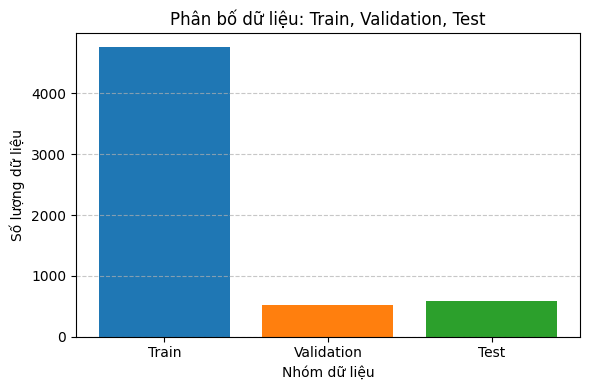

In [ ]:
data_counts = {
    'Train': len(train_dataset),
    'Validation': len(valid_dataset),
    'Test': len(test_dataset)
}

keys = list(data_counts.keys())
values = list(data_counts.values())

# Lấy màu từ colormap mặc định 'tab10'
cmap = plt.get_cmap('tab10')
colors = cmap(np.arange(len(values)))

plt.figure(figsize=(6, 4))
plt.bar(keys, values, color=colors)
plt.title('Phân bố dữ liệu: Train, Validation, Test')
plt.ylabel('Số lượng dữ liệu')
plt.xlabel('Nhóm dữ liệu')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## tokenizer load

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(
    "Alibaba-NLP/gte-multilingual-reranker-base",
    trust_remote_code=True
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

In [ ]:
def tokenize_fn(examples):
    res = tokenizer(
        examples["query"],
        examples["document"],
        truncation=True,
        padding="max_length",
        max_length=512
    )
    res["labels"] = [float(x) for x in examples["label"]]
    return res

In [ ]:
tokenized_train = train_dataset.map(tokenize_fn, batched=True, remove_columns=train_dataset.column_names)
tokenized_valid = valid_dataset.map(tokenize_fn, batched=True, remove_columns=valid_dataset.column_names)
tokenized_test  = test_dataset.map(tokenize_fn, batched=True, remove_columns=test_dataset.column_names)

Map:   0%|          | 0/4756 [00:00<?, ? examples/s]

Map:   0%|          | 0/529 [00:00<?, ? examples/s]

Map:   0%|          | 0/588 [00:00<?, ? examples/s]

## model

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    "Alibaba-NLP/gte-multilingual-reranker-base",
    trust_remote_code=True
)

config.json: 0.00B [00:00, ?B/s]

configuration.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/Alibaba-NLP/new-impl:
- configuration.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


modeling.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/Alibaba-NLP/new-impl:
- modeling.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


model.safetensors:   0%|          | 0.00/612M [00:00<?, ?B/s]

In [ ]:
def compute_metrics(pred):
    labels = pred.label_ids
    scores = pred.predictions.squeeze()
    preds = (scores > 0).astype(int)
    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds),
        "recall": recall_score(labels, preds),
        "f1": f1_score(labels, preds),
    }

In [ ]:
training_args = TrainingArguments(
    output_dir="./reranker_ckpt",
    overwrite_output_dir=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=8,
    num_train_epochs=10,
    weight_decay=0.25,
    fp16=True,
    warmup_ratio=0.1,
    save_total_limit=2,
    load_best_model_at_end=True,
    report_to="none",
    label_names=["labels"],
    remove_unused_columns=False
)

### train

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_valid,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

/tmp/ipykernel_2902/2669883495.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [ ]:
trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 0}.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.308600,0.146300,0.627599,0.582979,0.996364,0.735570
2,0.113800,0.130252,0.676749,0.619816,0.978182,0.758815
3,0.077600,0.142087,0.591682,0.561077,0.985455,0.715040
4,0.050600,0.153007,0.674858,0.620609,0.963636,0.754986
5,0.033900,0.155104,0.646503,0.599548,0.963636,0.739191


TrainOutput(global_step=375, training_loss=0.11691194089253744, metrics={'train_runtime': 1247.9558, 'train_samples_per_second': 38.11, 'train_steps_per_second': 0.601, 'total_flos': 8322251751075840.0, 'train_loss': 0.11691194089253744, 'epoch': 5.0})

### lưu

In [ ]:
model.save_pretrained("/content/drive/MyDrive/se365/rerank_model_VLQA")
tokenizer.save_pretrained("/content/drive/MyDrive/se365/rerank_model_VLQA")
print("Model saved!")

Model saved!
